# Урок 1.4. Переобучение, смещение и разброс, валидация

**Интерактивная версия:** `lessons/lesson_1_4/web/index.html`

После урока вы сможете:
- распознавать недообучение и переобучение по ошибкам на обучении и на новых данных;
- разложить ожидаемую ошибку на смещение², разброс и шум и вычислить их;
- читать кривые обучения и понимать роль усреднения и ранней остановки;
- организовать валидацию и кросс-валидацию без утечек.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import GBRegressor, RegressionTree, datasets, style
from gbcourse.metrics import mse
from gbcourse.plotting import plot_data, plot_truth, use_course_style
from gbcourse.rng import Mulberry32

use_course_style()
NOISE2 = 0.35**2

## 1. U-кривая: обучение против новых данных

40 обучающих точек синуса и 400 новых. Ошибка на обучении падает всегда, на новых данных — до поры.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


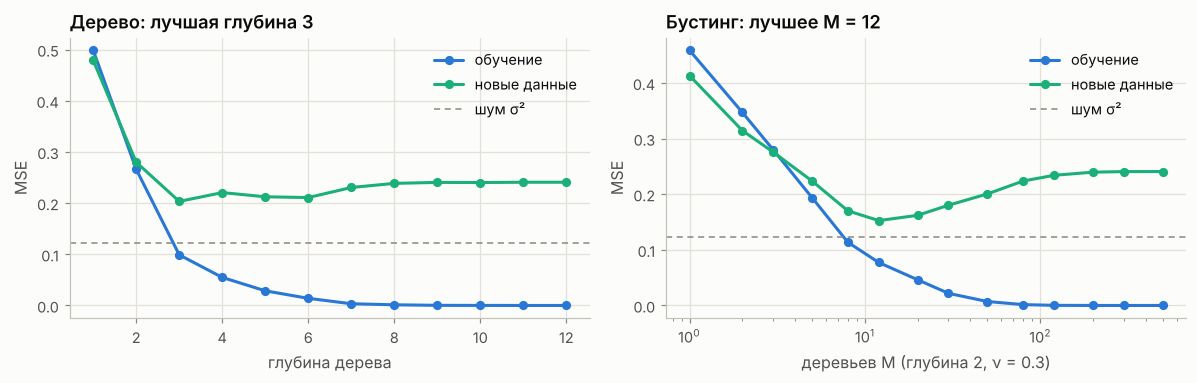

дерево: лучшая глубина 3 (MSE 0.203); глубина 12 — обучение 0.0000, новые 0.241
бустинг: лучшее M = 12 (MSE 0.153); M = 500 — обучение 0.0000, новые 0.241


In [2]:
X, y = datasets.regression_1d(kind="sine", n=40, noise=0.35, seed=2)
Xt, yt = datasets.regression_1d(kind="sine", n=400, noise=0.35, seed=102)
depths = range(1, 13)
tr = [mse(y, RegressionTree(max_depth=d).fit(X, -y).predict(X)) for d in depths]
te = [mse(yt, RegressionTree(max_depth=d).fit(X, -y).predict(Xt)) for d in depths]
gb = GBRegressor(n_estimators=500, learning_rate=0.3, max_depth=2).fit(X, y)
Ms = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120, 200, 300, 500]
gtr = [mse(y, gb.predict(X, n_iter=m)) for m in Ms]
gte = [mse(yt, gb.predict(Xt, n_iter=m)) for m in Ms]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(depths, tr, marker="o", color=style.ROLE["train"], label="обучение")
axes[0].plot(depths, te, marker="o", color=style.ROLE["test"], label="новые данные")
axes[0].set(xlabel="глубина дерева", ylabel="MSE", title=f"Дерево: лучшая глубина {depths[int(np.argmin(te))]}")
axes[1].semilogx(Ms, gtr, marker="o", color=style.ROLE["train"], label="обучение")
axes[1].semilogx(Ms, gte, marker="o", color=style.ROLE["test"], label="новые данные")
axes[1].set(xlabel="деревьев M (глубина 2, ν = 0.3)", ylabel="MSE", title=f"Бустинг: лучшее M = {Ms[int(np.argmin(gte))]}")
for ax in axes:
    ax.axhline(NOISE2, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="шум σ²")
    ax.legend()
fig.tight_layout()
plt.show()
print(f"дерево: лучшая глубина {depths[int(np.argmin(te))]} (MSE {min(te):.3f}); глубина 12 — обучение {tr[-1]:.4f}, новые {te[-1]:.3f}")
print(f"бустинг: лучшее M = {Ms[int(np.argmin(gte))]} (MSE {min(gte):.3f}); M = 500 — обучение {gtr[-1]:.4f}, новые {gte[-1]:.3f}")

## 2. Мишень: смещение² + разброс = средний квадрат промаха

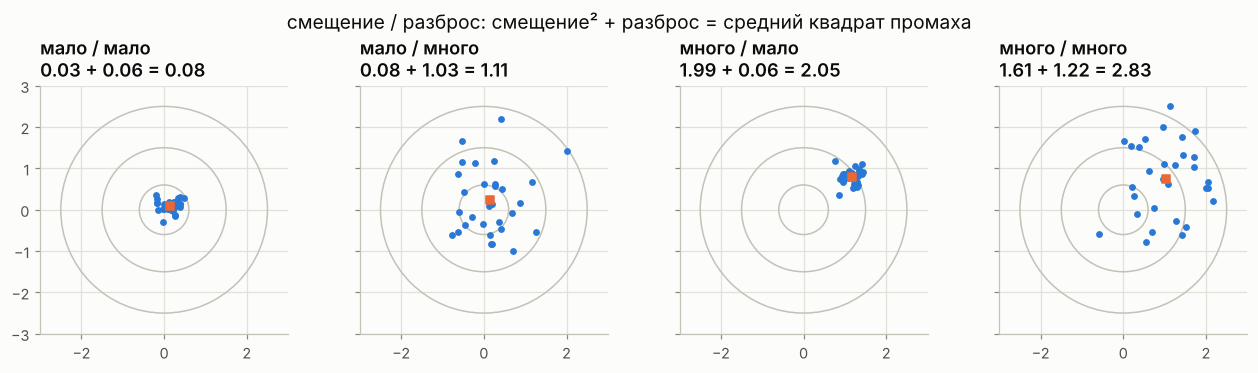

In [3]:
rng = Mulberry32(1)
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), sharex=True, sharey=True)
for ax, (bias, spread, title) in zip(axes, [(0.1, 0.25, "мало / мало"), (0.1, 1.1, "мало / много"), (1.4, 0.25, "много / мало"), (1.4, 1.1, "много / много")]):
    mu = bias * np.array([np.cos(np.radians(35)), np.sin(np.radians(35))])
    shots = np.array([[mu[0] + spread / np.sqrt(2) * rng.normal(), mu[1] + spread / np.sqrt(2) * rng.normal()] for _ in range(30)])
    mean = shots.mean(0)
    b2, var, msq = np.sum(mean**2), np.mean(np.sum((shots - mean) ** 2, 1)), np.mean(np.sum(shots**2, 1))
    for r in (2.5, 1.5, 0.6):
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color=style.AXIS))
    ax.scatter(shots[:, 0], shots[:, 1], s=12, color=style.BLUE)
    ax.scatter([mean[0]], [mean[1]], marker="s", color=style.ORANGE, zorder=3)
    ax.set(title=f"{title}\n{b2:.2f} + {var:.2f} = {msq:.2f}", aspect="equal", xlim=(-3, 3), ylim=(-3, 3))
fig.suptitle("смещение / разброс: смещение² + разброс = средний квадрат промаха")
fig.tight_layout()
plt.show()

## 3. Разложение ошибки на 30 обучающих выборках

глубина  1: смещение² 0.301  разброс 0.078  ожидаемая ошибка 0.501
глубина  2: смещение² 0.083  разброс 0.110  ожидаемая ошибка 0.315
глубина  3: смещение² 0.025  разброс 0.122  ожидаемая ошибка 0.269
глубина  4: смещение² 0.013  разброс 0.126  ожидаемая ошибка 0.261
глубина  5: смещение² 0.012  разброс 0.132  ожидаемая ошибка 0.267
глубина  6: смещение² 0.012  разброс 0.141  ожидаемая ошибка 0.276


глубина  7: смещение² 0.012  разброс 0.143  ожидаемая ошибка 0.278
глубина  8: смещение² 0.012  разброс 0.145  ожидаемая ошибка 0.280
глубина  9: смещение² 0.012  разброс 0.145  ожидаемая ошибка 0.280


глубина 10: смещение² 0.012  разброс 0.145  ожидаемая ошибка 0.280


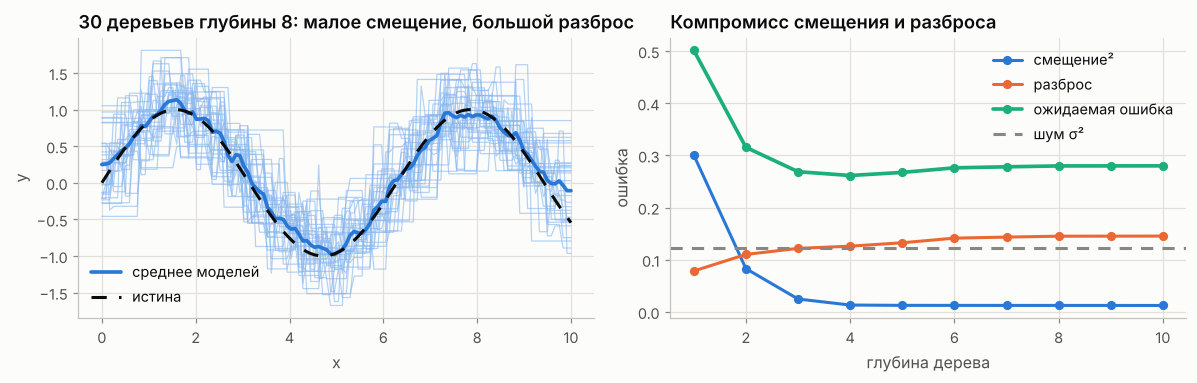

In [4]:
grid = np.linspace(0, 10, 120).reshape(-1, 1)
truth = np.sin(grid[:, 0])


def decompose(fit_predict, n: int = 30, B: int = 30):
    preds = np.array([fit_predict(*datasets.regression_1d(kind="sine", n=n, noise=0.35, seed=s)) for s in range(1, B + 1)])
    return np.mean((preds.mean(0) - truth) ** 2), np.mean(preds.var(0)), preds


rows = []
for d in range(1, 11):
    b2, v, _ = decompose(lambda X, y, d=d: RegressionTree(max_depth=d).fit(X, -y).predict(grid))
    rows.append((d, b2, v))
    print(f"глубина {d:2d}: смещение² {b2:.3f}  разброс {v:.3f}  ожидаемая ошибка {b2 + v + NOISE2:.3f}")
rows = np.array(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
_, _, preds = decompose(lambda X, y: RegressionTree(max_depth=8).fit(X, -y).predict(grid))
axes[0].plot(grid[:, 0], preds.T, color=style.ROLE["model_prev"], lw=0.8, alpha=0.6)
axes[0].plot(grid[:, 0], preds.mean(0), color=style.BLUE, lw=2.4, label="среднее моделей")
axes[0].plot(grid[:, 0], truth, color=style.INK, ls=(0, (5, 4)), label="истина")
axes[0].set(title="30 деревьев глубины 8: малое смещение, большой разброс", xlabel="x", ylabel="y")
axes[0].legend()
axes[1].plot(rows[:, 0], rows[:, 1], marker="o", color=style.BLUE, label="смещение²")
axes[1].plot(rows[:, 0], rows[:, 2], marker="o", color=style.ORANGE, label="разброс")
axes[1].plot(rows[:, 0], rows[:, 1] + rows[:, 2] + NOISE2, marker="o", color=style.AQUA, lw=2.4, label="ожидаемая ошибка")
axes[1].axhline(NOISE2, color=style.MUTED, ls=(0, (4, 3)), label="шум σ²")
axes[1].set(xlabel="глубина дерева", ylabel="ошибка", title="Компромисс смещения и разброса")
axes[1].legend()
fig.tight_layout()
plt.show()

Проверим разложение напрямую: средняя ошибка на новых данных должна совпасть с суммой смещения², разброса и шума.

In [5]:
Xn, yn = datasets.regression_1d(kind="sine", n=4000, noise=0.35, seed=999)
for d in (1, 4, 10):
    errs = []
    for s in range(1, 31):
        Xs, ys = datasets.regression_1d(kind="sine", n=30, noise=0.35, seed=s)
        errs.append(mse(yn, RegressionTree(max_depth=d).fit(Xs, -ys).predict(Xn)))
    b2, v, _ = decompose(lambda X, y, d=d: RegressionTree(max_depth=d).fit(X, -y).predict(grid))
    print(f"глубина {d:2d}: средняя ошибка на новых {np.mean(errs):.3f}  ≈  смещение² + разброс + шум = {b2 + v + NOISE2:.3f}")

глубина  1: средняя ошибка на новых 0.508  ≈  смещение² + разброс + шум = 0.501
глубина  4: средняя ошибка на новых 0.265  ≈  смещение² + разброс + шум = 0.261


глубина 10: средняя ошибка на новых 0.283  ≈  смещение² + разброс + шум = 0.280


## 4. Кривые обучения

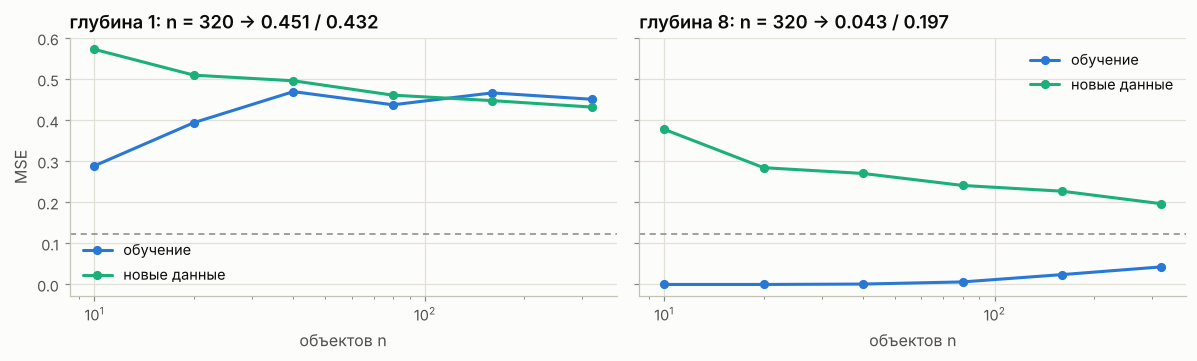

In [6]:
Xbig, ybig = datasets.regression_1d(kind="sine", n=500, noise=0.35, seed=999)
ns = [10, 20, 40, 80, 160, 320]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, d in zip(axes, (1, 8)):
    tr_, te_ = [], []
    for n in ns:
        a, b = [], []
        for s in range(1, 11):
            Xs, ys = datasets.regression_1d(kind="sine", n=n, noise=0.35, seed=s)
            t = RegressionTree(max_depth=d).fit(Xs, -ys)
            a.append(mse(ys, t.predict(Xs)))
            b.append(mse(ybig, t.predict(Xbig)))
        tr_.append(np.mean(a))
        te_.append(np.mean(b))
    ax.semilogx(ns, tr_, marker="o", color=style.ROLE["train"], label="обучение")
    ax.semilogx(ns, te_, marker="o", color=style.ROLE["test"], label="новые данные")
    ax.axhline(NOISE2, color=style.MUTED, ls=(0, (4, 3)), lw=1)
    ax.set(xlabel="объектов n", title=f"глубина {d}: n = 320 → {tr_[-1]:.3f} / {te_[-1]:.3f}")
    ax.legend()
axes[0].set_ylabel("MSE")
fig.tight_layout()
plt.show()

## 5. Усреднение коррелированных моделей

$\operatorname{Var}(\text{среднее } B) = \rho\sigma^2 + (1-\rho)\sigma^2/B$.

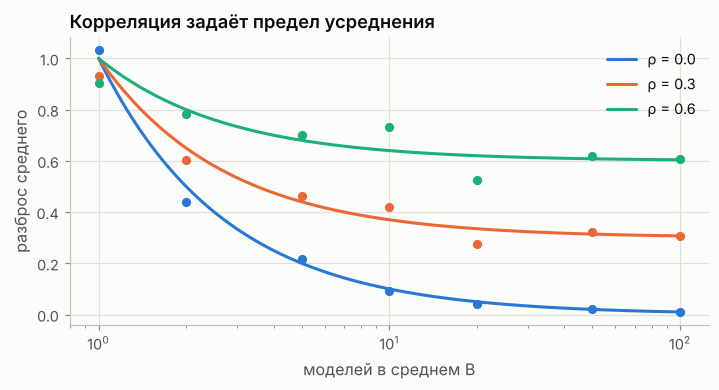

In [7]:
Bs = [1, 2, 5, 10, 20, 50, 100]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for rho, color in zip((0.0, 0.3, 0.6), style.SERIES):
    r = Mulberry32(11)
    sim = []
    for B in Bs:
        avg = []
        for _ in range(300):
            common = np.sqrt(rho) * r.normal()
            avg.append(np.mean([common + np.sqrt(1 - rho) * r.normal() for _ in range(B)]))
        sim.append(np.var(avg))
    bb = np.logspace(0, 2, 100)
    ax.semilogx(bb, rho + (1 - rho) / bb, color=color, label=f"ρ = {rho}")
    ax.semilogx(Bs, sim, "o", color=color)
ax.set(xlabel="моделей в среднем B", ylabel="разброс среднего", title="Корреляция задаёт предел усреднения")
ax.legend()
plt.show()

## 6. Ранняя остановка бустинга

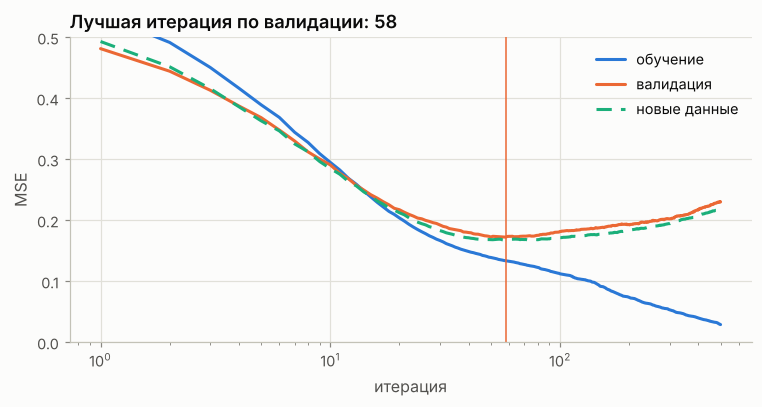

MSE на новых данных: при остановке 0.1680, после 500 деревьев 0.2176, лучшее возможное 0.1676
early_stopping_rounds=30: лучшая итерация 58 деревьев оставлено 58


In [8]:
Xs, ys = datasets.regression_1d(kind="sine", n=300, noise=0.4, seed=7)
X_tr, X_val, y_tr, y_val = datasets.train_test_split(Xs, ys, test_size=0.3, seed=0)
Xnew, ynew = datasets.regression_1d(kind="sine", n=500, noise=0.4, seed=107)
gb = GBRegressor(n_estimators=500, learning_rate=0.1, max_depth=2).fit(X_tr, y_tr, eval_set=(X_val, y_val))
val = 2 * np.array(gb.history_["eval"])  # history хранит ½·MSE
trn = 2 * np.array(gb.history_["train"])
new = [mse(ynew, gb.predict(Xnew, n_iter=m)) for m in range(501)]
best = int(np.argmin(val))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.semilogx(range(1, 501), trn[1:], color=style.ROLE["train"], label="обучение")
ax.semilogx(range(1, 501), val[1:], color=style.ROLE["valid"], label="валидация")
ax.semilogx(range(1, 501), new[1:], color=style.ROLE["test"], ls=(0, (5, 3)), label="новые данные")
ax.axvline(best, color=style.ROLE["valid"], lw=1)
ax.set(xlabel="итерация", ylabel="MSE", ylim=(0, 0.5), title=f"Лучшая итерация по валидации: {best}")
ax.legend()
plt.show()
print(f"MSE на новых данных: при остановке {new[best]:.4f}, после 500 деревьев {new[500]:.4f}, лучшее возможное {min(new):.4f}")

es = GBRegressor(n_estimators=500, learning_rate=0.1, max_depth=2, early_stopping_rounds=30).fit(X_tr, y_tr, eval_set=(X_val, y_val))
print("early_stopping_rounds=30: лучшая итерация", es.best_iteration_, "деревьев оставлено", es.n_trees_)

## 7. k-блочная кросс-валидация

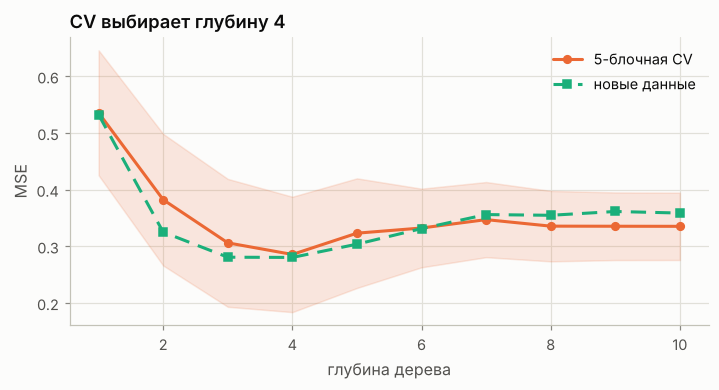

scikit-learn, глубина 4: CV MSE = 0.314 ± 0.076 (другое перемешивание — другое число)


In [9]:
Xk, yk = datasets.regression_1d(kind="sine", n=80, noise=0.4, seed=7)
Xkt, ykt = datasets.regression_1d(kind="sine", n=400, noise=0.4, seed=107)
perm = Mulberry32(0).permutation(len(yk))
fold = np.empty(len(yk), dtype=int)
fold[perm] = np.arange(len(yk)) % 5
cv_mean, cv_std, test_err = [], [], []
for d in range(1, 11):
    sc = [mse(yk[fold == j], RegressionTree(max_depth=d).fit(Xk[fold != j], -yk[fold != j]).predict(Xk[fold == j])) for j in range(5)]
    cv_mean.append(np.mean(sc))
    cv_std.append(np.std(sc))
    test_err.append(mse(ykt, RegressionTree(max_depth=d).fit(Xk, -yk).predict(Xkt)))
cv_mean, cv_std = np.array(cv_mean), np.array(cv_std)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.fill_between(range(1, 11), cv_mean - cv_std, cv_mean + cv_std, color=style.ORANGE, alpha=0.15)
ax.plot(range(1, 11), cv_mean, marker="o", color=style.ORANGE, label="5-блочная CV")
ax.plot(range(1, 11), test_err, marker="s", color=style.AQUA, ls=(0, (5, 3)), label="новые данные")
ax.set(xlabel="глубина дерева", ylabel="MSE", title=f"CV выбирает глубину {int(np.argmin(cv_mean)) + 1}")
ax.legend()
plt.show()

from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor

sk = -cross_val_score(DecisionTreeRegressor(max_depth=4), Xk, yk, cv=KFold(5, shuffle=True, random_state=0), scoring="neg_mean_squared_error")
print(f"scikit-learn, глубина 4: CV MSE = {sk.mean():.3f} ± {sk.std():.3f} (другое перемешивание — другое число)")

## 8. Утечка при отборе признаков

In [10]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

rng = Mulberry32(42)
Xn = np.array([[rng.normal() for _ in range(1000)] for _ in range(60)])
yn = np.array([rng.normal() for _ in range(60)])
cv = KFold(5, shuffle=True, random_state=0)
top = SelectKBest(f_regression, k=10).fit(Xn, yn).get_support()
wrong = cross_val_score(LinearRegression(), Xn[:, top], yn, cv=cv, scoring="r2")
right = cross_val_score(make_pipeline(SelectKBest(f_regression, k=10), LinearRegression()), Xn, yn, cv=cv, scoring="r2")
print(f"с утечкой:  R² = {wrong.mean():.3f}")
print(f"без утечки: R² = {right.mean():.3f}")

с утечкой:  R² = 0.426
без утечки: R² = -0.208


## Упражнения

1. Модель A: 0.45 / 0.47, модель B: 0.02 / 0.38 (обучение / валидация), шум 0.12. Диагноз?
2. Посчитайте смещение² и разброс для выстрелов (1, 1), (1, −1), (3, 0).
3. Как меняются смещение и разброс дерева глубины 8 при росте n с 30 до 120?
4. Найдите лучшее M бустинга при ν = 0.3 и ν = 0.05.
5. Разброс среднего при ρ = 0.3 и ρ = 0.1 для B = 1…1000.
6. Ранняя остановка для ν ∈ {1, 0.3, 0.1, 0.03}.
7. Обычная и повторённая кросс-валидация: разброс оценок.
8. Что не так, если CV использовали и для выбора, и для итоговой оценки?
9. Утечка при отборе признаков для k = 5, 10, 50.

<details><summary>Решения</summary>

`python lessons/lesson_1_4/exercises/solutions.py`
</details>